# ProvTrack – RTFM Event Log Demo

End-to-end provenance tracking over the **Road Traffic Fine Management (RTFM)** event log.
The analysis uses the helper functions from `event_enricher.py` exactly as an analyst would —
**no changes to the analysis code are required**; the middleware intercepts every function
call transparently through AST rewriting.

Pipeline:
1. Load the event log with `pd.read_csv`
2. Aggregate to a case log with `create_case_log`
3. Add relative case time with `event_add_relative_case_time`
4. Pivot activity start times with `case_add_activity_start_times`
5. Derive `Delay Send` as a raw pandas column assignment
6. Classify illegal delays with `case_log.apply(...)`

> **Prerequisites**: `uv pip install -e ".[full]"` from the project root.
>
> **Dataset**: place `rtfm_full.csv` in `examples/jupyter/data/`, or run the
> sample-generation cell to create a synthetic version automatically.

## 0 – Path setup

In [1]:
import sys
from pathlib import Path

# Walk up from cwd to find the project root (contains pyproject.toml).
_here = Path.cwd()
PROJECT_ROOT = _here
for _candidate in [_here, *_here.parents]:
    if (_candidate / "pyproject.toml").exists():
        PROJECT_ROOT = _candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Add examples/ to sys.path so the utils package (event_enricher etc.) is importable.
EXAMPLES_DIR = PROJECT_ROOT / "examples"
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

INPUT_FILE_NAME  = "rtfm_full.csv"
CASE_ID_COL      = "case:concept:name"
TIMESTAMP_COL    = "time:timestamp"
ACTIVITY_COL     = "concept:name"

data_path = Path("../data") / INPUT_FILE_NAME

print("Project root:", PROJECT_ROOT)
print("Examples dir:", EXAMPLES_DIR)
print("Data file   :", data_path.resolve(),
      "found" if data_path.exists() else "NOT FOUND (run the sample-generation cell)")

Project root: c:\Users\ABernalCaunedo\PhD_Code\new_prototype\pmprov
Examples dir: c:\Users\ABernalCaunedo\PhD_Code\new_prototype\pmprov\examples
Data file   : C:\Users\ABernalCaunedo\PhD_Code\new_prototype\pmprov\examples\data\rtfm_full.csv found


### Optional: generate a synthetic RTFM sample

Skip this cell if you have the real `rtfm_full.csv`.  
The synthetic data mirrors the RTFM schema exactly so every downstream step works identically.

In [2]:
import pandas as pd
import random

if not data_path.exists():
    data_path.parent.mkdir(parents=True, exist_ok=True)
    random.seed(42)
    _activities = [
        "Create Fine", "Send Fine", "Insert Fine Notification",
        "Add penalty", "Send for Credit Collection", "Payment",
    ]
    _rows = []
    for _case_num in range(1, 51):  # 50 synthetic cases
        _case_id = f"case_{_case_num:03d}"
        _base = pd.Timestamp("2006-01-01") + pd.Timedelta(days=random.randint(0, 365))
        _offset = 0
        _acts = ["Create Fine", "Send Fine"]
        if random.random() > 0.3:
            _acts.append("Insert Fine Notification")
        if random.random() > 0.5:
            _acts.append("Add penalty")
        _acts.append("Send for Credit Collection" if random.random() > 0.5 else "Payment")
        for _act in _acts:
            _offset += random.randint(10, 180)
            _rows.append({
                CASE_ID_COL:   _case_id,
                TIMESTAMP_COL: _base + pd.Timedelta(days=_offset),
                ACTIVITY_COL:  _act,
                "amount":      round(random.uniform(20, 500), 2),
                "org:resource": str(random.randint(100, 999)),
                "points":      random.randint(0, 10),
                "matricola":   f"M{random.randint(1000, 9999)}",
            })
    pd.DataFrame(_rows).to_csv(data_path, index=False)
    print(f"Synthetic sample written to {data_path} ({len(_rows)} events, {_case_num} cases)")
else:
    print(f"Real dataset found: {data_path}")

Real dataset found: ..\data\rtfm_full.csv


## 1 – Initialise the tracker and register operation types

`init_jupyter()` injects the AST transformer into the running IPython kernel.  
After this cell every top-level function call is automatically captured — no
changes to analysis code are needed.

Because `OperationType` cannot be inferred from a function name alone,
we register semantic labels for the `event_enricher` functions using the
**direct form** of `operation_type`.

In [3]:
from tracker import init_jupyter, omit_functions, operation_type, enable_logging

enable_logging()    # WARNING + ERROR → stderr
enable_logging(level="DEBUG")

from utils.event_enricher import (
    create_case_log,
    event_add_relative_case_time,
    case_add_activity_start_times,
)

rt = init_jupyter(
    history_name="RTFM event log exploration",
    branch_name="main",
    db_path="provenance.db",
    artifact_dir="artifacts",
)

# Register semantic labels for third-party / shared functions
operation_type("data_loading",         pd.read_csv)
operation_type("case_aggregation",     create_case_log)
operation_type("attribute_derivation", event_add_relative_case_time)
operation_type("attribute_derivation", case_add_activity_start_times)
operation_type("case_filter",          pd.DataFrame.apply)

# Extend the omit list with any project-specific noise functions.
omit_functions("nunique", "mean", "sum", "min", "max")

print("Session ID   :", rt.session_id)
print("History name :", rt._history.name)
print("Branch       :", rt._branch.name)
print("Root state   :", rt._root_state_id)

Session ID   : e7236888-df4d-4559-92a8-ba70bbf432ab
History name : RTFM event log exploration
Branch       : main
Root state   : f1362ac6-f107-479e-b9f5-8351d2afda68


## 2 – RTFM analysis pipeline

The six steps below are **unmodified analyst code**.  
The middleware intercepts every function call automatically.

In [4]:
# Step 1 – load the event log
event_log = pd.read_csv(
    '../data/' + INPUT_FILE_NAME,
    dtype={'org:resource': str, 'matricola': str},
    parse_dates=[TIMESTAMP_COL],
)
print(f"Loaded {len(event_log):,} events across {event_log[CASE_ID_COL].nunique():,} cases")
event_log.head(3)

[pmprov] 2026-06-05 14:12:17 WARNING runtime.trace_step – parameter value serialisation failed (step='param_values', func_name='pd.read_csv', error=PydanticSerializationError(Unable to serialize unknown type: <class 'type'>))


Loaded 561,470 events across 150,370 cases


,amount,org:resource,dismissal,concept:name,vehicleClass,totalPaymentAmount,lifecycle:transition,time:timestamp,article,points,case:concept:name,expense,notificationType,lastSent,paymentAmount,matricola
0,35.0,561,NIL,Create Fine,A,0.0,complete,2006-07-24 00:00:00+00:00,157.0,0.0,A1,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,Send Fine,NaN,NaN,complete,2006-12-05 00:00:00+00:00,NaN,NaN,A1,11.0,NaN,NaN,NaN,NaN
2,35.0,561,NIL,Create Fine,A,0.0,complete,2006-08-02 00:00:00+00:00,157.0,0.0,A100,NaN,NaN,NaN,NaN,NaN


In [5]:
# Step 2 – aggregate to one row per case
case_log = create_case_log(event_log)
print(f"Case log: {len(case_log):,} cases, {len(case_log.columns)} columns")
case_log.head(3)

Case log: 150,370 cases, 4 columns


,start_time,end_time,no_of_events,duration
case:concept:name,,,,
A1,2006-07-24 00:00:00+00:00,2006-12-05 00:00:00+00:00,2,134 days
A100,2006-08-02 00:00:00+00:00,2009-03-30 00:00:00+00:00,5,971 days
A10000,2007-03-09 00:00:00+00:00,2008-09-09 00:00:00+00:00,5,550 days


In [6]:
# Step 3 – add relative case time (timedelta from case start) to the event log
event_log = event_add_relative_case_time(event_log, CASE_ID_COL, TIMESTAMP_COL)
print(f"rel_time range: {event_log['rel_time'].min()} – {event_log['rel_time'].max()}")
event_log[[CASE_ID_COL, ACTIVITY_COL, TIMESTAMP_COL, 'rel_time']].head(4)

rel_time range: 0 days 00:00:00 – 4372 days 00:00:00


,case:concept:name,concept:name,time:timestamp,rel_time
0,A1,Create Fine,2006-07-24 00:00:00+00:00,0 days
1,A1,Send Fine,2006-12-05 00:00:00+00:00,134 days
2,A100,Create Fine,2006-08-02 00:00:00+00:00,0 days
3,A100,Send Fine,2006-12-12 00:00:00+00:00,132 days


In [7]:
# Step 4 - pivot first-occurrence times of each activity into the case log
case_log = case_add_activity_start_times(case_log, event_log, CASE_ID_COL, ACTIVITY_COL, 'rel_time')
time_cols = [c for c in case_log.columns if c.endswith('::start')]
print(f"Activity start-time columns: {time_cols}")
case_log.reset_index()[[CASE_ID_COL, 'duration'] + time_cols].head(3)

Activity start-time columns: ['Create_Fine::start', 'Send_Fine::start', 'Insert_Fine_Notification::start', 'Add_penalty::start', 'Send_for_Credit_Collection::start', 'Payment::start', 'Insert_Date_Appeal_to_Prefecture::start', 'Send_Appeal_to_Prefecture::start', 'Receive_Result_Appeal_from_Prefecture::start', 'Notify_Result_Appeal_to_Offender::start', 'Appeal_to_Judge::start']


,case:concept:name,duration,Create_Fine::start,Send_Fine::start,Insert_Fine_Notification::start,Add_penalty::start,Send_for_Credit_Collection::start,Payment::start,Insert_Date_Appeal_to_Prefecture::start,Send_Appeal_to_Prefecture::start,Receive_Result_Appeal_from_Prefecture::start,Notify_Result_Appeal_to_Offender::start,Appeal_to_Judge::start
0,A1,134 days,0 days,134 days,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,A100,971 days,0 days,132 days,166 days,226 days,971 days,NaT,NaT,NaT,NaT,NaT,NaT
2,A10000,550 days,0 days,130 days,146 days,206 days,NaT,550 days,NaT,NaT,NaT,NaT,NaT


In [8]:
# Step 5 - derive Delay Send (timedelta from Create Fine to Send Fine, converted to days)
# Plain pandas column assignment - not intercepted by the middleware, just raw analysis.
case_log['Delay Send'] = (
    case_log['Send_Fine::start'] - case_log['Create_Fine::start']
).dt.total_seconds() / 86400

print(f"Delay Send (days) - mean: {case_log["Delay Send"].mean():.1f}, "
      f"median: {case_log["Delay Send"].median():.1f}")
case_log.reset_index()[[CASE_ID_COL, 'Create_Fine::start', 'Send_Fine::start', 'Delay Send']].head(5)

Delay Send (days) - mean: 87.5, median: 88.0


,case:concept:name,Create_Fine::start,Send_Fine::start,Delay Send
0,A1,0 days,134 days,134.0
1,A100,0 days,132 days,132.0
2,A10000,0 days,130 days,130.0
3,A10001,0 days,120 days,120.0
4,A10004,0 days,119 days,119.0


In [9]:
# Step 6 – classify cases with an illegal delay (threshold: 90 days)
# case_log.apply(...) IS a tracked call — the middleware will record this step.
is_illegal_delay = case_log.apply(lambda case: case['Delay Send'] > 90.0, axis=1)

print(f"Cases flagged as illegal delay (> 90 days): {is_illegal_delay.sum()}")
is_illegal_delay.head()

Cases flagged as illegal delay (> 90 days): 49772


case:concept:name
A1        True
A100      True
A10000    True
A10001    True
A10004    True
dtype: bool

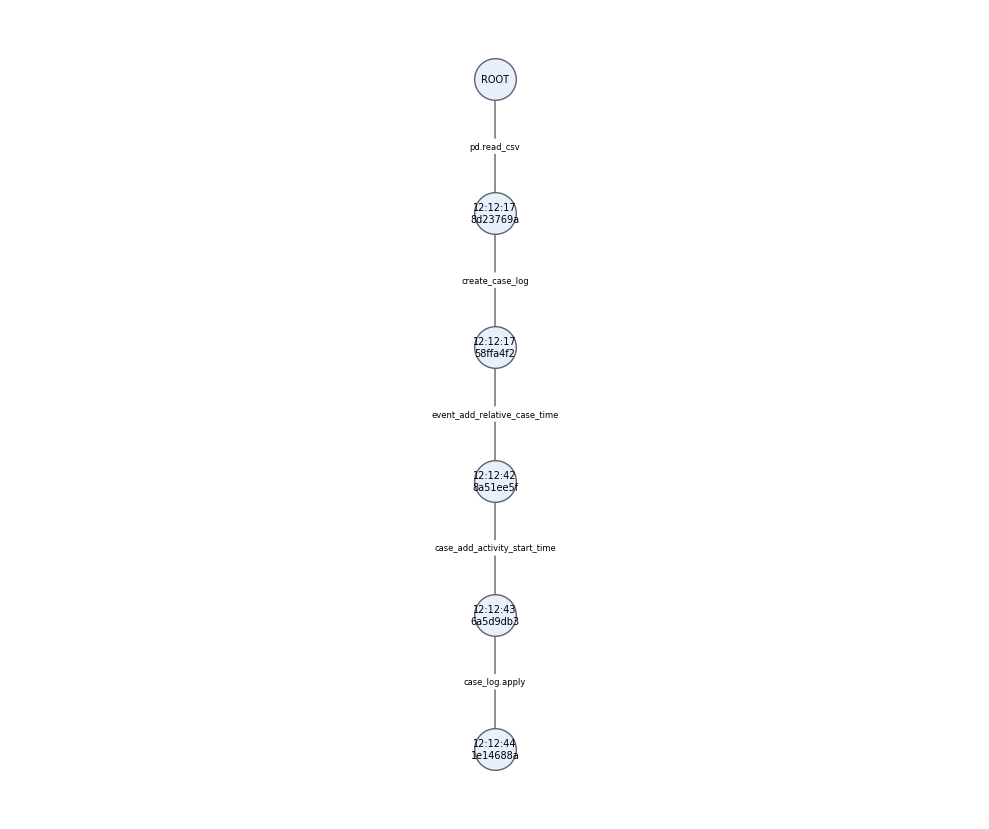

In [10]:
# Static DAG plot - shows the full provenance graph as a directed acyclic graph.
# Nodes are labelled with timestamp + state_id[:8]; edges with the function name.
rt.show_graph()

## 4 – Auto-branching: re-run with a different illegal-delay threshold

Re-running the `case_log.apply(...)` cell with threshold `132.0` instead of `90.0`
triggers **Case-1 auto-branching**.

The middleware detects that `apply` was already called on the current branch with
a different argument fingerprint, sets the divergence point to the input state of
the previous call, and creates a new branch automatically.

In [11]:
# Re-run with a stricter threshold — auto-branch fires here
is_illegal_delay = case_log.apply(lambda case: case['Delay Send'] > 132.0, axis=1)

print(f"Cases flagged as illegal delay (> 132 days): {is_illegal_delay.sum()}")
print(f"Current branch : '{rt._branch.name}'  (auto-created)")
print(f"Branch ID      : {rt._branch.branch_id[:8]}…")

Cases flagged as illegal delay (> 132 days): 14106
Current branch : 'branch-case_log.apply-6a5d9db3'  (auto-created)
Branch ID      : e6c7e345…


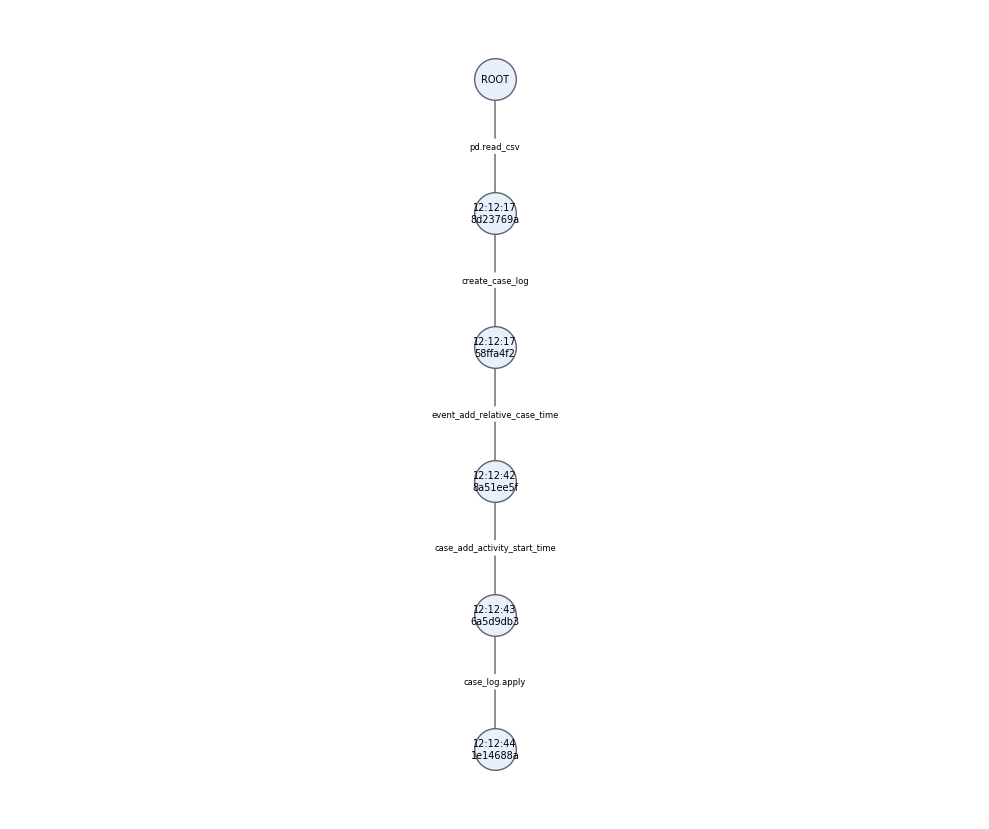

In [12]:
# Confirm the branch node was registered and is visible in the graph
rt.show_graph()

## 5 – Manual checkout: resume from a previous state

`rt.checkout(state_id)` implements **Case-2 branching**: explicitly rewind to any
previously recorded `AnalysisState` and explore a different path.

Here we go back to the state produced just after `create_case_log` and compute a
different enrichment — skipping the activity start-time pivot.

In [13]:
# List all recorded analysis states with their full state_id.
# Copy the state_id of the node you want to branch from.
rt.list_states()

,state_id,timestamp,branch_name,produced_by_step_id,derived_from_state_id,artifact_state_ids
0,f1362ac6-f107-479e-b9f5-8351d2afda68,2026-06-05 12:12:15,main,NaN,NaN,
1,8d23769a-3209-4b35-9a40-77fada8486b9,2026-06-05 12:12:17,main,d92c1e5d-c412-4044-be6e-9bd37fcb43ba,f1362ac6-f107-479e-b9f5-8351d2afda68,56664597-9456-4707-a1e8-692a83a63299
2,58ffa4f2-e2f4-4d8a-9c41-6d1a61012f5d,2026-06-05 12:12:17,main,a7f6ef28-39d3-46a3-98de-889a318b2863,8d23769a-3209-4b35-9a40-77fada8486b9,58cab6f3-18f7-44d7-9181-d98970399923
3,8a51ee5f-08ab-4aa6-a764-7f5217d1b6de,2026-06-05 12:12:42,main,fb2e7b79-6efe-4b14-b25b-efb42e701a31,58ffa4f2-e2f4-4d8a-9c41-6d1a61012f5d,ac460ed4-ae4a-493e-b2c6-4b64baa98863
4,6a5d9db3-a6ed-4222-9a02-9d135b5b17f0,2026-06-05 12:12:43,main,74118bc9-8899-4e2d-883d-60c0e2719c38,8a51ee5f-08ab-4aa6-a764-7f5217d1b6de,864f9205-c892-4d5b-9cd4-062dceeedeba
5,1e14688a-74b3-4b0c-8952-babfc33a5dbd,2026-06-05 12:12:44,main,ac3a85ef-ac5d-440c-a270-9a7441b9473c,6a5d9db3-a6ed-4222-9a02-9d135b5b17f0,
6,bdaa4672-a258-4dd3-ac18-6ba647303d26,2026-06-05 12:12:48,branch-case_log.apply-6a5d9db3,8afc6537-5b05-4296-a141-48fbe0f31aef,6a5d9db3-a6ed-4222-9a02-9d135b5b17f0,


In [14]:
# Copy the full state_id of the node you want to branch from.
# Find it in the graph widget: select a node and the detail panel shows state_id.
# In the future, clicking a node in the live graph will fill this in automatically.$
CHECKOUT_STATE_ID = rt.list_states()["state_id"][1]

branch = rt.checkout(CHECKOUT_STATE_ID, branch_name="duration-filter-path")
print(f"New branch : '{branch.name}'")
print(f"Starts at  : {branch.starts_at_state_id[:8]}...")

New branch : 'duration-filter-path'
Starts at  : 8d23769a...


In [15]:
# Alternative path on the new branch: classify by total case duration
# instead of Delay Send -- no pivot step needed.
long_cases = case_log.apply(lambda case: case["duration"].days > 200, axis=1)
print(f"Branch '{rt._branch.name}': {long_cases.sum()} cases with duration > 200 days")

Branch 'duration-filter-path': 74949 cases with duration > 200 days


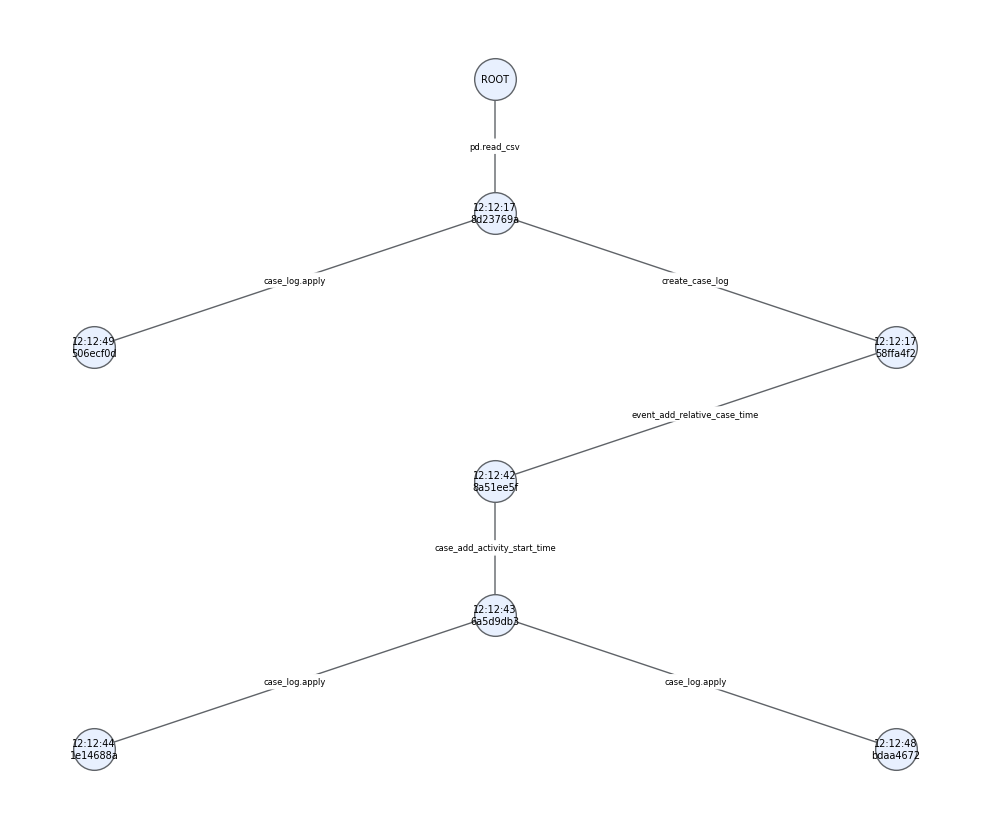

In [16]:
# Updated graph -- the manual checkout branch should now appear.
rt.show_graph()

## 6 - Provenance Graph Widget

In [17]:
# Interactive inspector - DAG image on the left, step selector + detail panel on the right.
# Select any step to see: branch, operation type, raw line, delta, and a preview of the
# Parquet artifact produced by that step (toggle between Preview and Summary).
rt.show_graph_widget()